In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get data

In [4]:
origin_2024_Q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/orig_2024Q1.txt",sep="|",header=None)
perform_2024_q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/perf_2024Q1.txt",sep="|",header=None)

/var/folders/t2/_pywhmm106s1vjr8m0jr12hm0000gn/T/ipykernel_15861/2225058536.py:2: DtypeWarning: Columns (0: 3, 1: 7, 2: 23, 3: 24, 4: 28) have mixed types. Specify dtype option on import or set low_memory=False.
  perform_2024_q1_df = pd.read_csv("historical_data_2024/historical_data_2024Q1/perf_2024Q1.txt",sep="|",header=None)


In [5]:
origination_columns = [
    "classic_fico",
    "first_payment_date",
    "first_time_homebuyer_indicator",
    "maturity_date",
    "msa_or_metropolitan_division",
    "mi_percentage",
    "number_of_units",
    "occupancy_status",
    "original_cltv",
    "original_dti",
    "original_upb",
    "original_ltv",
    "original_interest_rate",
    "channel",
    "prepayment_penalty_indicator",
    "amortization_type",
    "property_state",
    "property_type",
    "postal_code",
    "loan_identifier",
    "loan_purpose",
    "original_loan_term",
    "number_of_borrowers",
    "seller_name",
    "super_conforming_flag",
    "pre_harp_loan_sequence_number",
    "special_eligibility_program",
    "harp_indicator",
    "property_valuation_method",
    "interest_only_indicator",
    "vantagescore_4_0"
]
performance_columns = [
    "loan_identifier",
    "period",
    "current_actual_upb",
    "current_loan_delinquency_status",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "underwriting_defect_and_major_servicing_defect_settlement_date",
    "modification_flag",
    "zero_balance_code",
    "zero_balance_effective_date",
    "current_interest_rate",
    "current_non_interest_bearing_upb",
    "due_date_of_last_paid_installment",
    "mi_recoveries",
    "net_sales_proceeds",
    "non_mi_recoveries",
    "total_expenses",
    "legal_costs",
    "maintenance_and_preservation_costs",
    "taxes_and_insurance",
    "miscellaneous_expenses",
    "actual_loss",
    "cumulative_modification_costs",
    "interest_rate_step_indicator",
    "payment_deferral_flag",
    "estimated_ltv",
    "zero_balance_removal_upb",
    "delinquent_accrued_interest",
    "delinquency_due_to_disaster",
    "borrower_assistance_plan",
    "current_period_modification_costs",
    "current_interest_bearing_upb",
    "mortgage_insurance_cancellation_indicator",
    "servicer_name",
    "bankruptcy_cramdown_costs"
]

assert len(performance_columns) == 35

origin_2024_Q1_df.columns=origination_columns
perform_2024_q1_df.columns=performance_columns




# Preliminary

## Target table creation

In [6]:
origin_2024_Q1 = origin_2024_Q1_df.copy()
perform_2024_q1 = perform_2024_q1_df.copy()

In [7]:
assert origin_2024_Q1["loan_identifier"].is_unique

performance_with_age = perform_2024_q1.merge(
    origin_2024_Q1[
        ["loan_identifier", "first_payment_date"]
    ],
    on="loan_identifier",
    how="left",
    validate="many_to_one"
)

performance_with_age["first_payment_date_parsed"] = pd.to_datetime(
    performance_with_age["first_payment_date"].astype("string"),
    format="%Y%m",
    errors="coerce"
)

performance_with_age["period_parsed"] = pd.to_datetime(
    performance_with_age["period"].astype("string"),
    format="%Y%m",
    errors="coerce"
)

performance_with_age["original_loan_age"] = (
    (
        performance_with_age["period_parsed"].dt.year
        - performance_with_age["first_payment_date_parsed"].dt.year
    ) * 12
    +
    (
        performance_with_age["period_parsed"].dt.month
        - performance_with_age["first_payment_date_parsed"].dt.month
    )
    + 1
)

target_df = (
    performance_with_age.loc[
        performance_with_age["original_loan_age"].eq(20),
        [
            "loan_identifier",
            "current_loan_delinquency_status"
        ]
    ]
    .rename(
        columns={
            "current_loan_delinquency_status":
                "status_at_month_20"
        }
    )
    .reset_index(drop=True)
)

status_column = "status_at_month_20"

target_df[status_column] = (
    target_df[status_column]
    .astype("string")
    .str.strip()
    .str.upper()
)

numeric_mask = target_df[status_column].str.fullmatch(
    r"\d+"
)

target_df.loc[numeric_mask, status_column] = (
    target_df.loc[numeric_mask, status_column]
    .str.zfill(2)
)

status_numeric = pd.to_numeric(
    target_df[status_column],
    errors="coerce"
)

target_df["target_90plus"] = (
    status_numeric.ge(3)
    | target_df[status_column].eq("RA")
).astype("Int8")
unavailable_status = (
    target_df[status_column].isna()
    | target_df[status_column].eq("XX")
)

target_df.loc[
    unavailable_status,
    "target_90plus"
] = pd.NA

pd.crosstab(
    target_df[status_column],
    target_df["target_90plus"],
    dropna=False
)

target_df = target_df[
    ["loan_identifier", "target_90plus"]
].copy()

model_df = origin_2024_Q1.merge(
    target_df,
    on="loan_identifier",
    how="inner",
    validate="one_to_one"
)


## Data Cleaning

In [8]:
number_of_borrowers_map={
    3:2,
    4:2,
    5:2,
    6:2,
    7:2,
    8:2,
    9:2,
    10:2
}


In [9]:
model_df["classic_fico"] = model_df["classic_fico"].replace(to_replace=9999 , value=np.nan)
model_df["first_time_homebuyer_indicator"] = model_df["first_time_homebuyer_indicator"].replace(to_replace=9 , value=np.nan)
model_df["first_time_homebuyer_indicator"] = (model_df["first_time_homebuyer_indicator"] == "Y").astype(int)
model_df["mi_percentage"] = model_df["mi_percentage"].replace(to_replace=999 , value=np.nan)
model_df["number_of_units"] = model_df["number_of_units"].replace(to_replace=99 , value=np.nan)
model_df["occupancy_status"] = model_df["occupancy_status"].replace(to_replace=9 , value=np.nan)
model_df["original_cltv"] = model_df["original_cltv"].replace(to_replace=999 , value=np.nan)
model_df["original_dti"] = model_df["original_dti"].replace(to_replace=999 , value=np.nan)
model_df["original_ltv"] = model_df["original_ltv"].replace(to_replace=999 , value=np.nan)
model_df["channel"] = model_df["channel"].replace(to_replace=9 , value=np.nan)
model_df["prepayment_penalty_indicator"] = (model_df["prepayment_penalty_indicator"] == "Y").astype(int)
model_df["property_type"] = model_df["property_type"].replace(to_replace=99 , value=np.nan)
model_df["postal_code"] = model_df["postal_code"].replace(to_replace=000 , value=np.nan)
model_df["loan_purpose"] = model_df["loan_purpose"].replace(to_replace=9 , value=np.nan)
model_df["number_of_borrowers"] = model_df["number_of_borrowers"].replace(to_replace=99 , value=np.nan)
model_df["number_of_borrowers"] = model_df["number_of_borrowers"].replace(number_of_borrowers_map)
model_df["super_conforming_flag"] = (model_df["super_conforming_flag"] == "Y").astype(int)
model_df["special_eligibility_program"] = model_df["special_eligibility_program"].fillna("NONE_OR_NA")
model_df["property_valuation_method"] = model_df["property_valuation_method"].replace(to_replace=7 , value=np.nan)
model_df["property_valuation_method"] = model_df["property_valuation_method"].astype(str)


del model_df["loan_identifier"]
del model_df["pre_harp_loan_sequence_number"]
del model_df["harp_indicator"]
del model_df["interest_only_indicator"]
del model_df["vantagescore_4_0"]


# EDA

In [10]:
model_df_eda = model_df.copy()
origin_2024_Q1_eda= origin_2024_Q1.copy()

## Basic exploration

In [11]:
n_loans = origin_2024_Q1.shape[0]
print(f"Number of original loans : {n_loans}")
print(f"Number of lians with 20 month target : {model_df.shape[0]}")
print(f"Number of excluded loans : {n_loans-model_df.shape[0]} , that is {round(((n_loans-model_df.shape[0])/n_loans)*100,3)} %")

Number of original loans : 215009
Number of lians with 20 month target : 183002
Number of excluded loans : 32007 , that is 14.886 %


In [12]:
defective_df =  model_df.target_90plus.value_counts(dropna=False)
global_defective = model_df.target_90plus.mean() 

print(f"Non defective loans in 20 months time with a defectivness of 90+ days : {defective_df.loc[0]} \nDefective loans in 20 months time with a defectivness of 90+ days : {defective_df.iloc[1]}")
print(f"\n\nGlobal defective rate : {round(global_defective,5)} %")
print("\nThe data id highly unbalanced , this have to be taken into consideration for evaluation")

Non defective loans in 20 months time with a defectivness of 90+ days : 181722 
Defective loans in 20 months time with a defectivness of 90+ days : 1280


Global defective rate : 0.00699 %

The data id highly unbalanced , this have to be taken into consideration for evaluation


## Analize target coverage

In [13]:
origin_2024_Q1_eda["has_month_20_target"]=(
    origin_2024_Q1_eda["loan_identifier"].isin(target_df["loan_identifier"]).astype("int8")
)

In [14]:
# What happend to those not chosen loans : evaluating bias

excluded_loans_identifier = origin_2024_Q1_eda.loc[origin_2024_Q1_eda["has_month_20_target"].eq(0),"loan_identifier"]
performance_excluded_loans = perform_2024_q1.loc[perform_2024_q1["loan_identifier"].isin(excluded_loans_identifier)].copy()

performance_excluded_loans = performance_excluded_loans.sort_values(["loan_identifier","period"]).groupby("loan_identifier").tail(1)

In [15]:
zero_balance_code_df = performance_excluded_loans["zero_balance_code"].copy()
zero_balance_map = {
    1:"voluntary payoff or maturity",
    96:"defect before event",
    2:"third-party sale",
    9:"REOdisposition",
    16:"reperforming-loan sale",
    3:"short sale/charge-off",
    15:"whole-loan sale"
}

zero_balance_code_df = zero_balance_code_df.map(zero_balance_map).fillna("Missing")
zero_balance_code_distribution = zero_balance_code_df.value_counts()
zero_balance_code_distribution

zero_balance_code
voluntary payoff or maturity    30942
defect before event               854
Missing                           185
third-party sale                   13
REOdisposition                      8
short sale/charge-off               4
reperforming-loan sale              1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='zero_balance_code'>

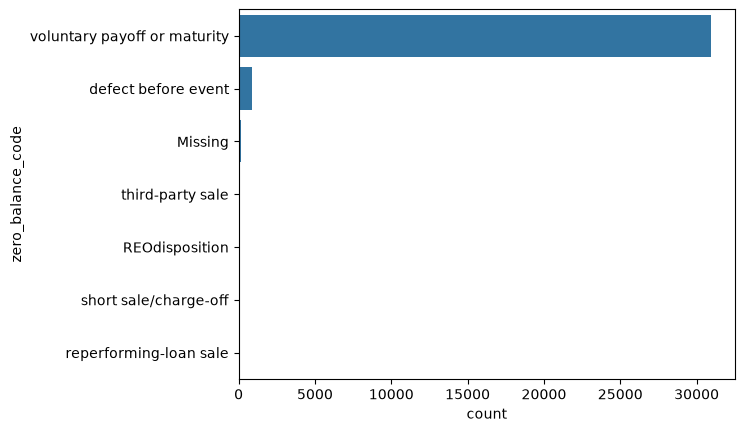

In [16]:
#sns.barplot(zero_balance_code_distribution.drop(index=["Missing"]),orient="h")
sns.barplot(zero_balance_code_distribution,orient="h")

In [17]:
default_events = [
    "third-party sale",
    "REOdisposition",
    "short sale/charge-off"
]
non_default_events = [
    "voluntary payoff or maturity",
    "reperforming-loan sale"
]
uncertain_events = [
    "defect before event",  
    "Missing"               
]

defaults = zero_balance_code_distribution.loc[default_events].sum()
non_default = zero_balance_code_distribution.loc[non_default_events].sum()
uncertain = zero_balance_code_distribution.loc[uncertain_events].sum()
total = zero_balance_code_df.shape[0]

print(f"Non-default loans are : {non_default} and are the {round(non_default/total,3)} % of non cosidered loans")
print(f"Uncertain loans are : {uncertain} and are the {round(uncertain/total,3)} % of non cosidered loans")
print(f"\n\nDefault loans are : {defaults} and are the {round(defaults/total,3)} % of non cosidered loans")
print(f"This loans are {round(defaults/n_loans,4)} % of the total loans")
print("The number of not considered default is negligible")


Non-default loans are : 30943 and are the 0.967 % of non cosidered loans
Uncertain loans are : 1039 and are the 0.032 % of non cosidered loans


Default loans are : 25 and are the 0.001 % of non cosidered loans
This loans are 0.0001 % of the total loans
The number of not considered default is negligible
